
===== SPORTS =====

Missing values:
chieu_cao_cm       0
can_nang_kg        0
toc_do_100m_s      0
so_ban_thang       0
so_phut_thi_dau    0
dtype: int64

Describe:
       chieu_cao_cm  can_nang_kg  toc_do_100m_s  so_ban_thang  so_phut_thi_dau
count    100.000000   100.000000     100.000000    100.000000       100.000000
mean     174.231290    70.334569      12.135328     14.780000      1437.440000
std       10.462542    14.305034       2.193551      8.046054       835.458494
min      148.802549    41.218432       5.000000      1.000000        48.000000
25%      168.874401    57.915092      10.995649      8.000000       830.750000
50%      174.061708    71.261608      12.113757     15.000000      1348.500000
75%      180.008525    78.072557      13.056656     22.000000      2056.000000
max      220.000000   110.802537      25.000000     29.000000      2966.000000


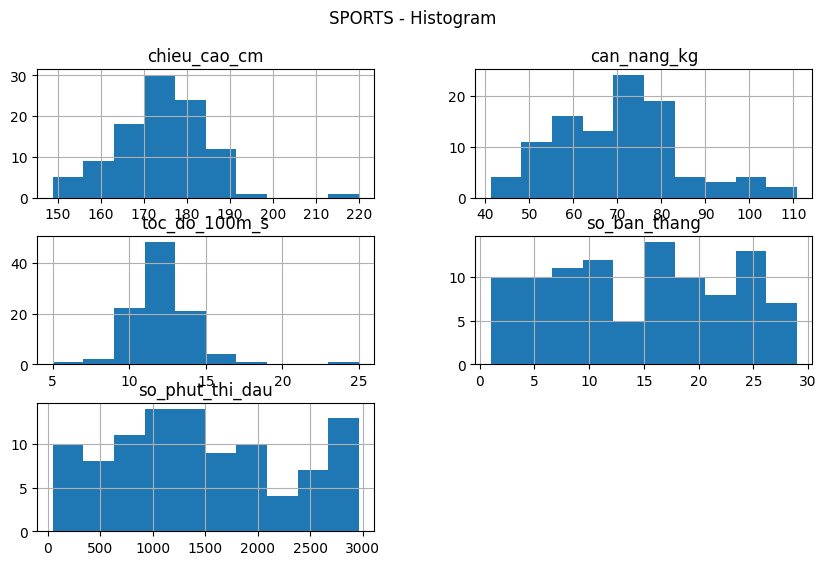

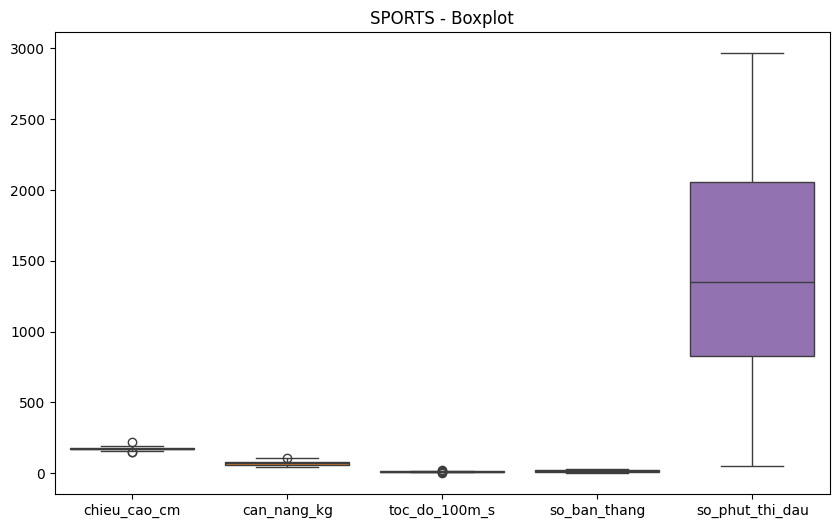

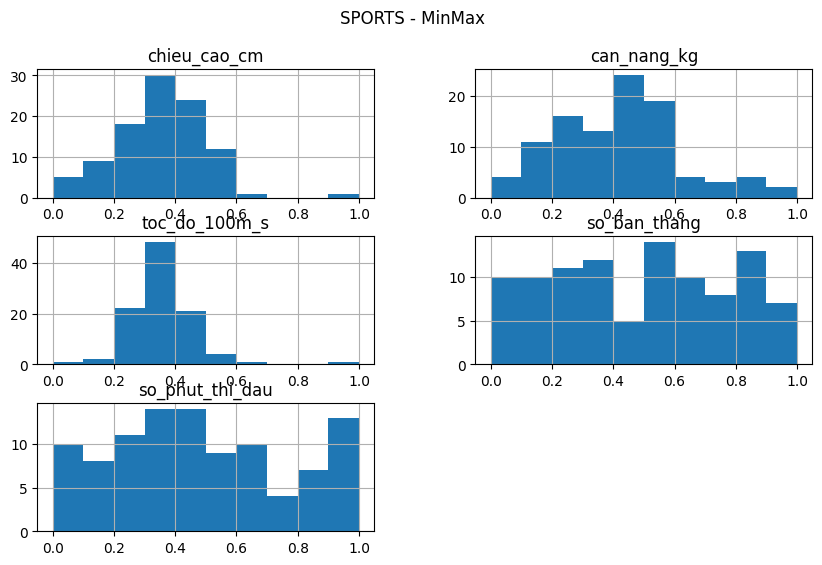

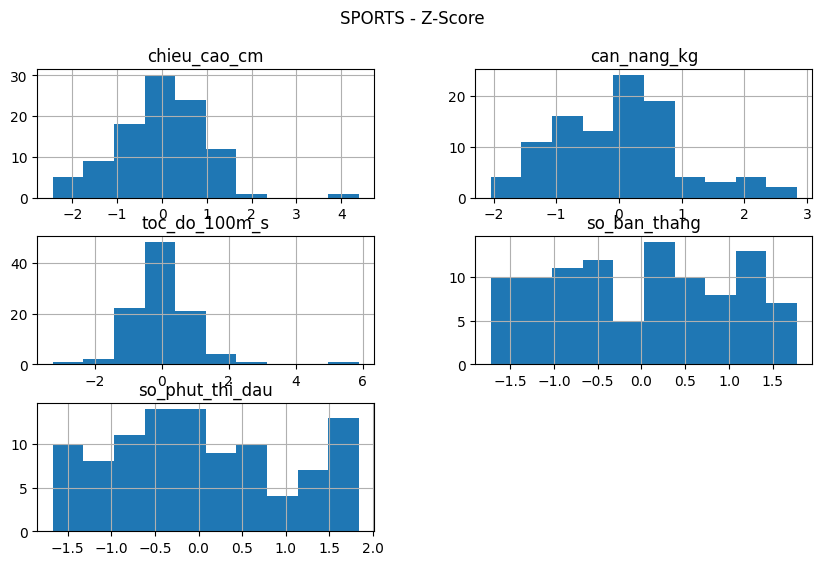


===== HEALTH =====

Missing values:
BMI                  0
huyet_ap_mmHg        0
nhip_tim_bpm         0
cholesterol_mg_dl    0
dtype: int64

Describe:
              BMI  huyet_ap_mmHg  nhip_tim_bpm  cholesterol_mg_dl
count  100.000000     100.000000    100.000000         100.000000
mean    23.967027     119.264104     70.280135         199.804870
std      5.238193      19.347547     10.599687          29.258869
min     10.000000      82.925332     43.031134         137.542118
25%     20.224820     107.918865     64.464403         178.709188
50%     23.696402     118.336822     69.564759         203.543562
75%     26.769769     128.100339     77.226957         218.357696
max     50.000000     250.000000     95.733598         278.971462


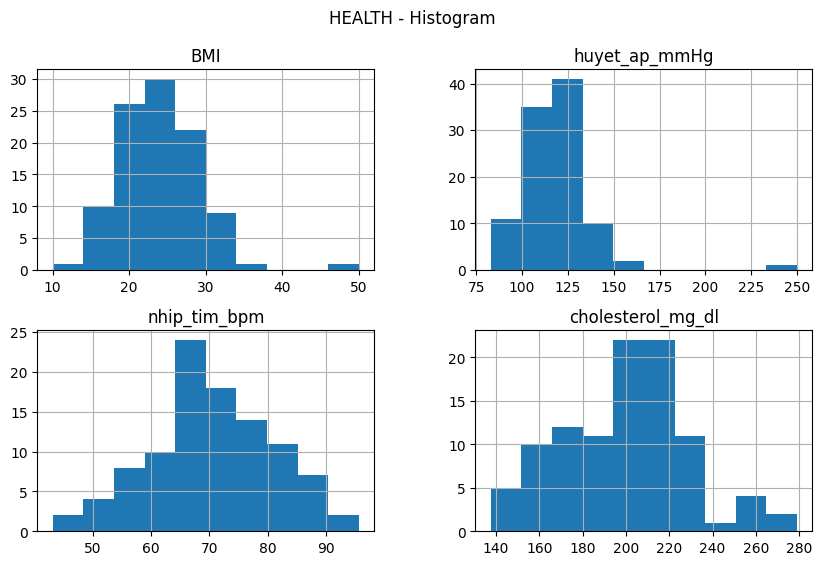

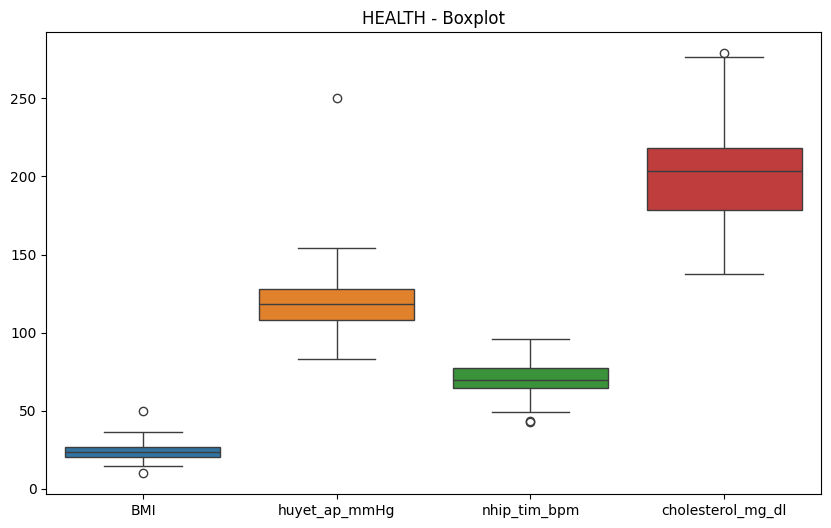

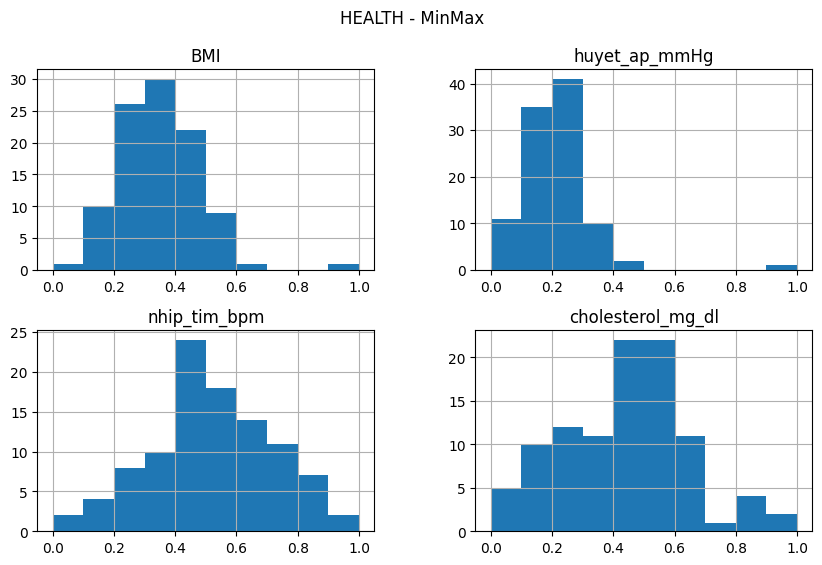

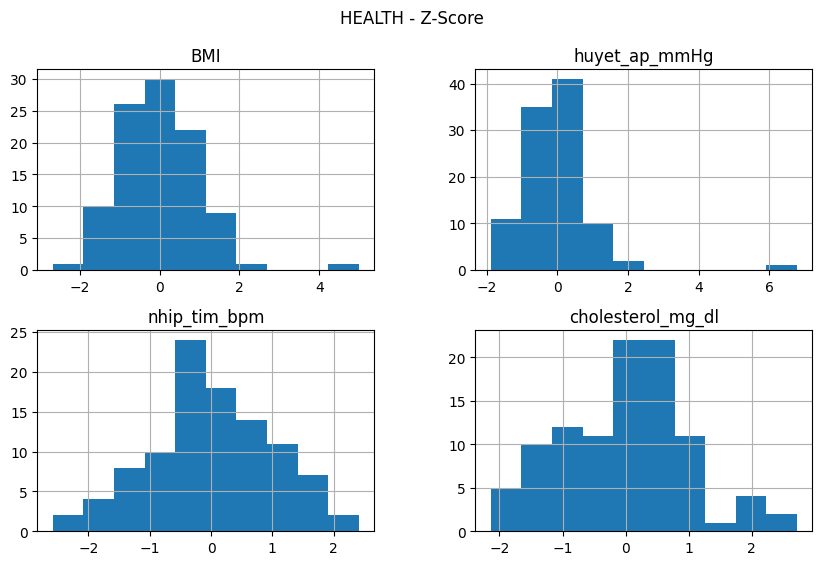


===== FINANCE =====

Missing values:
doanh_thu_musd    0
loi_nhuan_musd    0
so_nhan_vien      0
EPS               0
dtype: int64

Describe:
       doanh_thu_musd  loi_nhuan_musd  so_nhan_vien         EPS
count      100.000000      100.000000    100.000000  100.000000
mean       674.642882       56.903082    987.750000    1.982097
std       1058.779862       53.352990    601.387275    1.121290
min        196.851177      -22.716380     16.000000   -0.455125
25%        396.215304       34.539784    460.250000    1.319709
50%        517.840477       55.665623    956.500000    1.988484
75%        680.358810       71.549486   1429.500000    2.719773
max      10000.000000      500.000000   1999.000000    4.946213


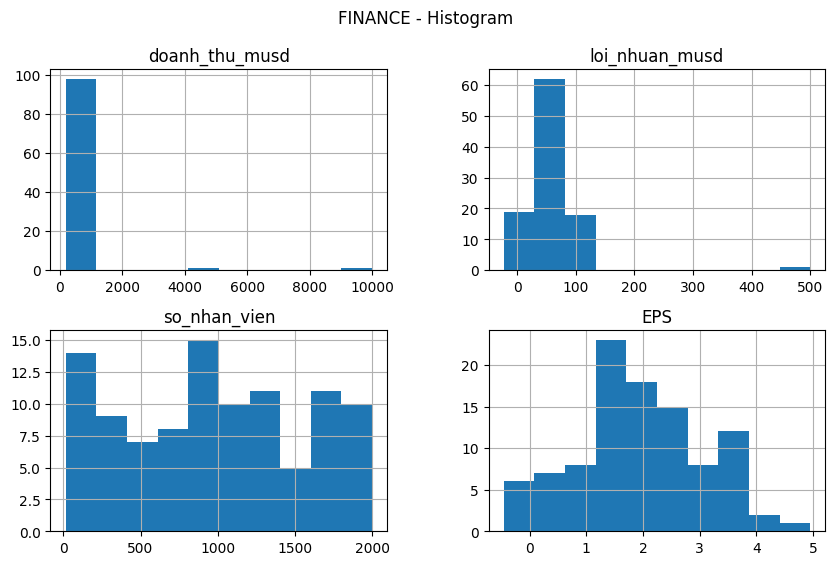

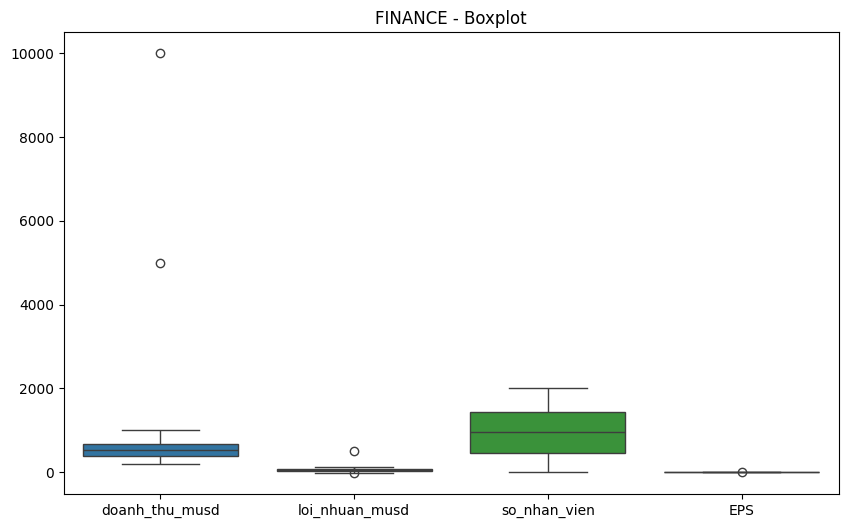

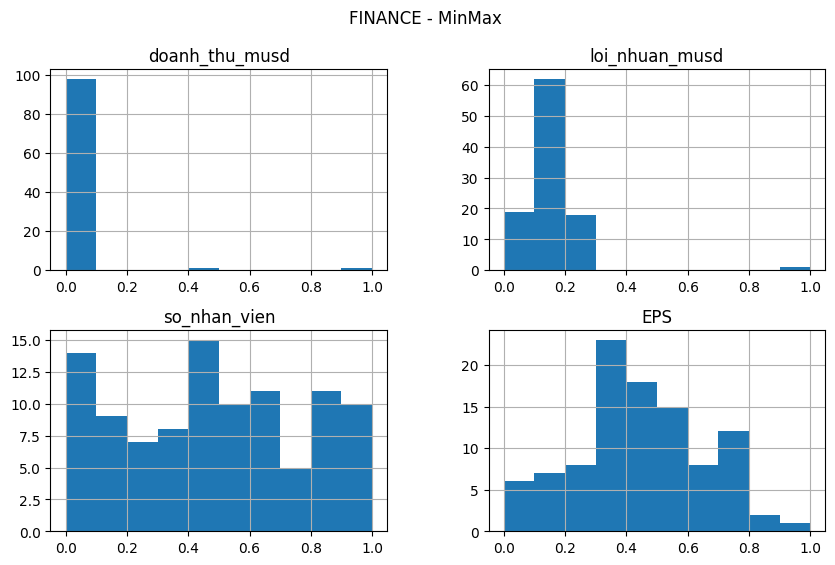

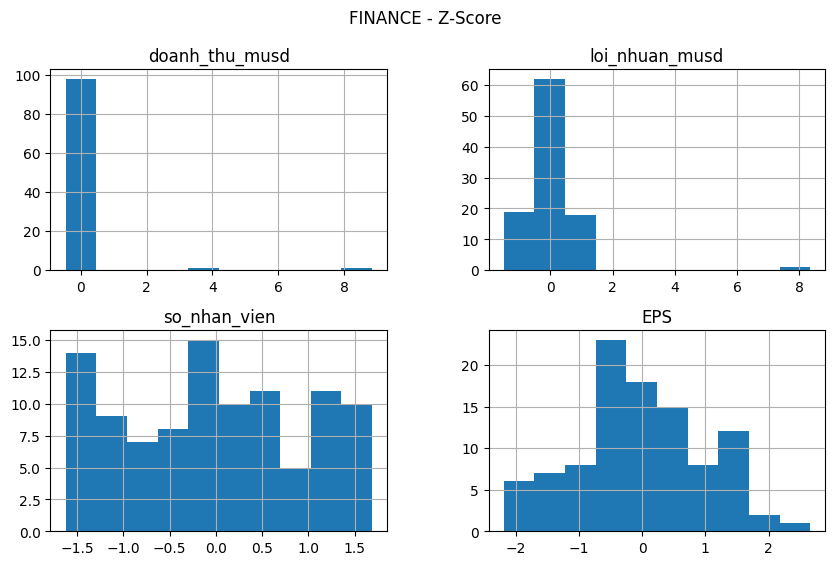

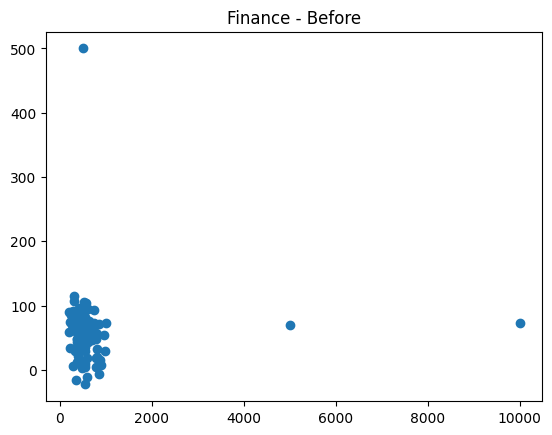

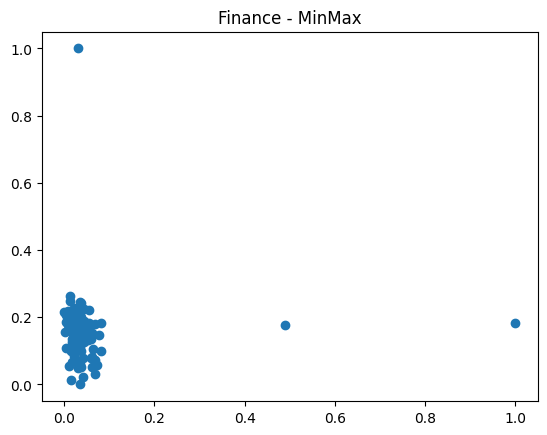

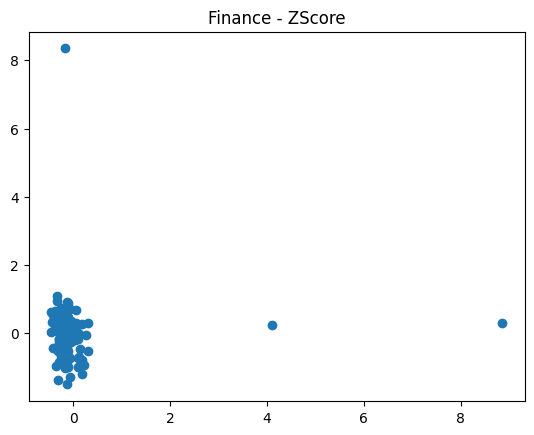


===== GAMING =====

Missing values:
gio_choi         0
diem_tich_luy    0
so_level         0
so_vat_pham      0
dtype: int64

Describe:
         gio_choi  diem_tich_luy    so_level  so_vat_pham
count  100.000000     100.000000  100.000000   100.000000
mean   116.323287    4758.682792   24.130000   105.710000
std     95.900437    2721.626236   12.772805    58.821644
min    -20.822588   -1776.856165    1.000000     1.000000
25%     71.648243    3388.207430   14.000000    58.500000
50%    113.140095    4667.406186   23.000000   110.500000
75%    139.888716    6475.813843   35.000000   151.250000
max    800.000000   20000.000000   49.000000   199.000000


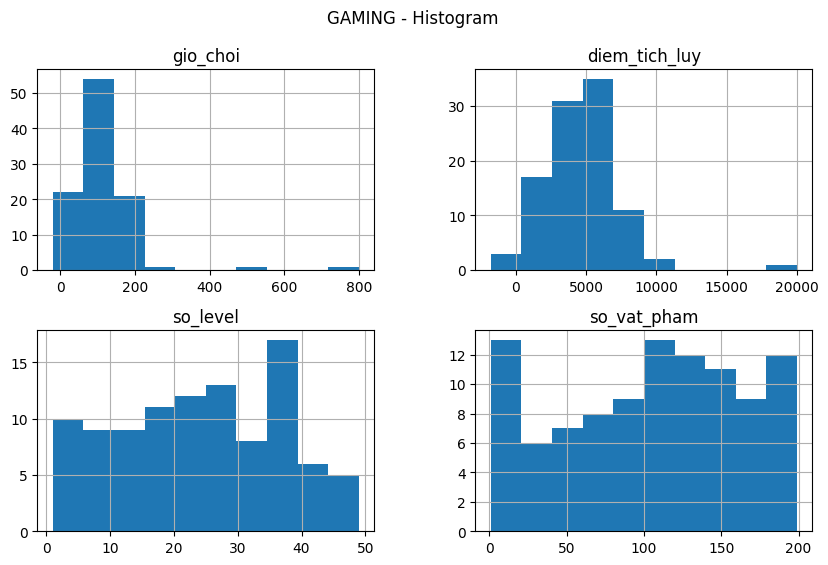

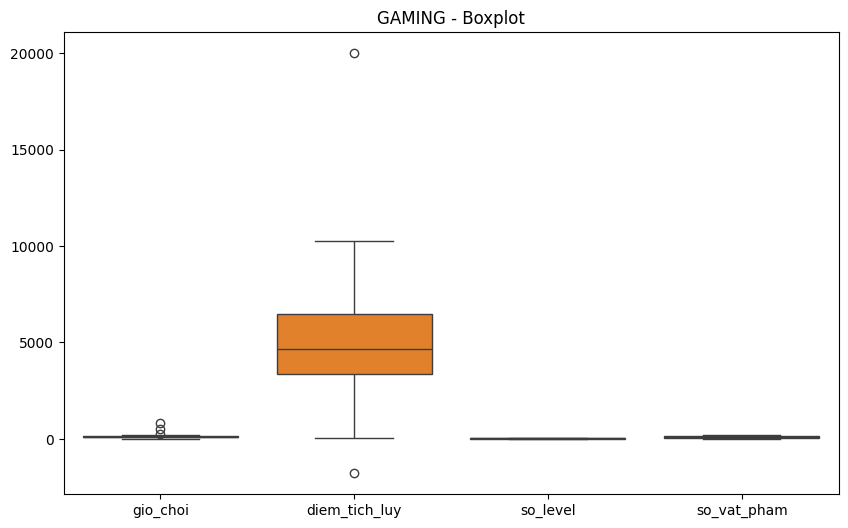

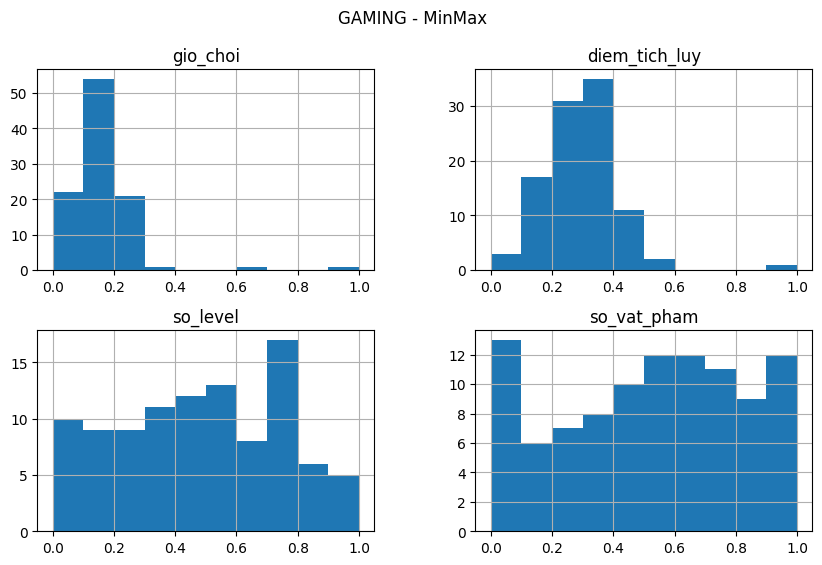

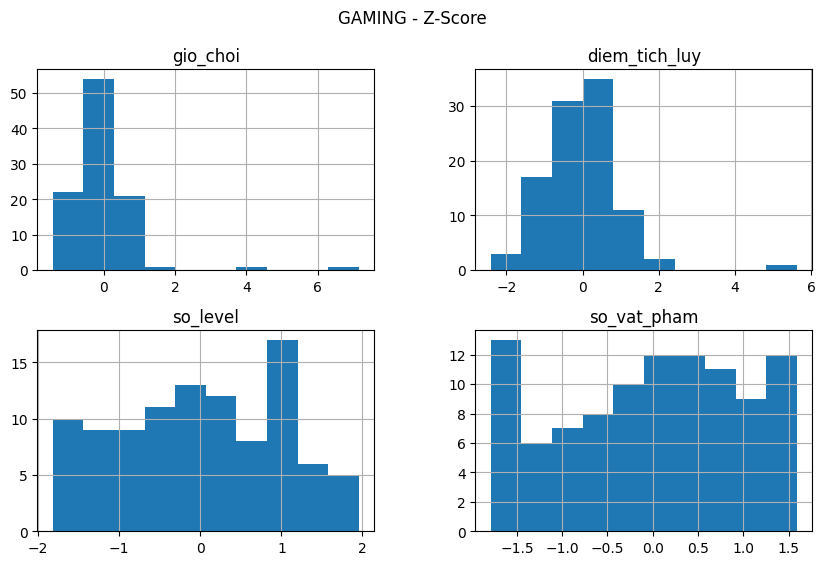

In [1]:
# =========================
# IMPORT THƯ VIỆN
# =========================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# =========================
# LOAD DATA
# =========================
sports = pd.read_csv('/content/ITA105_Lab_3_Sports.csv')
health = pd.read_csv('/content/ITA105_Lab_3_Health.csv')
finance = pd.read_csv('/content/ITA105_Lab_3_Finance.csv')
gaming = pd.read_csv('/content/ITA105_Lab_3_Gaming.csv')

# =========================
# HÀM XỬ LÝ CHUNG
# =========================
def analyze_data(df, name):
    print(f"\n===== {name} =====")

    # Missing values
    print("\nMissing values:")
    print(df.isnull().sum())

    # Thống kê
    print("\nDescribe:")
    print(df.describe())

    # Histogram
    df.hist(figsize=(10,6))
    plt.suptitle(f"{name} - Histogram")
    plt.show()

    # Boxplot
    plt.figure(figsize=(10,6))
    sns.boxplot(data=df)
    plt.title(f"{name} - Boxplot")
    plt.show()

    # =========================
    # CHUẨN HÓA
    # =========================
    scaler_minmax = MinMaxScaler()
    scaler_zscore = StandardScaler()

    df_minmax = pd.DataFrame(scaler_minmax.fit_transform(df), columns=df.columns)
    df_zscore = pd.DataFrame(scaler_zscore.fit_transform(df), columns=df.columns)

    # Histogram so sánh
    df_minmax.hist(figsize=(10,6))
    plt.suptitle(f"{name} - MinMax")
    plt.show()

    df_zscore.hist(figsize=(10,6))
    plt.suptitle(f"{name} - Z-Score")
    plt.show()

    return df_minmax, df_zscore


# =========================
# BÀI 1 - SPORTS
# =========================
sports_minmax, sports_zscore = analyze_data(sports, "SPORTS")

# =========================
# BÀI 2 - HEALTH
# =========================
health_minmax, health_zscore = analyze_data(health, "HEALTH")

# =========================
# BÀI 3 - FINANCE
# =========================
finance_minmax, finance_zscore = analyze_data(finance, "FINANCE")

# Scatter trước và sau
plt.scatter(finance.iloc[:,0], finance.iloc[:,1])
plt.title("Finance - Before")
plt.show()

plt.scatter(finance_minmax.iloc[:,0], finance_minmax.iloc[:,1])
plt.title("Finance - MinMax")
plt.show()

plt.scatter(finance_zscore.iloc[:,0], finance_zscore.iloc[:,1])
plt.title("Finance - ZScore")
plt.show()

# =========================
# BÀI 4 - GAMING
# =========================
gaming_minmax, gaming_zscore = analyze_data(gaming, "GAMING")